# Cloning the Repo

In [1]:
#!git clone https://github.com/Tahoni01/Continual-hate-speech-detection.git
%cd Continual-hate-speech-detection

[WinError 2] Impossibile trovare il file specificato: 'Continual-hate-speech-detection'
c:\Uni\Continual-hate-speech-detection


# Install all the necessary library

In [2]:
%pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Cella 1
import torch
print(torch.__version__)           # 2.6.0+cu128
print(torch.cuda.is_available())   # True
print(torch.cuda.get_device_properties(0).major)  # 12

2.7.0+cu128
True
12


In [4]:
# Cella 2 — solo se cella 1 passa
from transformers import AutoTokenizer

c:\Uni\Continual-hate-speech-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Cella 3 — solo se cella 2 passa
from models.model_builder import CustomClassifier

In [6]:
#import torch
from dataset.df_loader import (getdf_davidson, getdf_hatexplain)
from dataset.stream_generator import (create_continual_stream, online_stream)
#from transformers import (AutoTokenizer, AutoConfig)
#from models.model_builder import CustomClassifier
from models.trainer import ContinualTrainer

## Check if a GPU is avaible

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

DEVICE: cuda


### Getting the datasets

In [8]:
print("Loading datasets...")

df_dv = getdf_davidson()
df_hx = getdf_hatexplain()

print("Davidson:", df_dv.shape)
print("HateXplain:", df_hx.shape)

Loading datasets...
                                                text      label    source
0  rt as a woman you shouldnt complain about clea...     normal  davidson
1  rt boy dats coldtyga dwn bad for cuffin dat ho...  offensive  davidson
2  rt dawg rt you ever fuck a bitch and she start...  offensive  davidson
3                          rt she look like a tranny  offensive  davidson
4  rt the shit you hear about me might be true or...  offensive  davidson
                                                text       label      source
0  i dont think im getting my baby them white 9 h...      normal  hatexplain
1  we cannot continue calling ourselves feminists...      normal  hatexplain
2                      nawt yall niggers ignoring me      normal  hatexplain
3  user i am bit confused coz chinese ppl can not...  hatespeech  hatexplain
4  this bitch in whataburger eating a burger with...  hatespeech  hatexplain
Davidson: (24275, 3)
HateXplain: (20144, 3)


### Creating the datastream

In [10]:
full_stream = create_continual_stream(
    df_list=[df_dv, df_hx],
    batch_size=10
)

### Creating the tokenizer and the pretrained model + custom head

In [11]:
tokenizer = AutoTokenizer.from_pretrained("distilroberta-base")

model = CustomClassifier(
    model_name="distilroberta-base",
    num_labels=3,
    )

model.to(device)

CustomClassifier(
  (backbone): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm):

## Training Session

In [12]:
import matplotlib.pyplot as plt
from models.trainer import ContinualTrainer
from strategy.replay import ReplayStrategy
from strategy.distillation import DistillationStrategy
from strategy.ewc import EWCStrategy
from utils.metrics import compute_accuracy, compute_f1
from utils.plot_utils import (
    plot_loss,
    plot_batch_metrics,
    plot_conf_matrix,
    plot_classwise_accuracy,
    plot_label_distribution,
    plot_strategy_comparison,
    plot_forgetting
)

In [13]:
# ─── CONFIG ──────────────────────────────────────────────────────────────────

BATCH_SIZE = 10
BUFFER_SIZE = 200
LR = 1e-5
label_map = {"hatespeech": 0, "offensive": 1, "normal": 2}

# ─── SPLIT STREAM PER SORGENTE ───────────────────────────────────────────────

stream_davidson   = [b for b in full_stream if b["source"].iloc[0] == "davidson"]
stream_hatexplain = [b for b in full_stream if b["source"].iloc[0] == "hatexplain"]

# ─── STRATEGY ────────────────────────────────────────────────────────────────

strategy = ReplayStrategy(buffer_size=BUFFER_SIZE)
# strategy = EWCStrategy(lambda_=0.4)
# strategy = DistillationStrategy(alpha=0.5, temperature=2.0)

# ─── TRAINER ─────────────────────────────────────────────────────────────────

trainer = ContinualTrainer(model=model, tokenizer=tokenizer, device=device, lr=LR)
trainer.add_strategy(strategy)

# ─── TRAIN TASK 1 — Davidson ─────────────────────────────────────────────────

print("=== Task 1: Davidson ===")
losses_dv, preds_dv, labels_dv = trainer.train_continual(stream_davidson, label_map)
trainer.on_task_end(stream_davidson, label_map)

acc_dv = compute_accuracy(preds_dv, labels_dv)
f1_dv  = compute_f1(preds_dv, labels_dv)
print(f"Davidson — Acc: {acc_dv:.4f} | F1: {f1_dv:.4f}")

# ─── TRAIN TASK 2 — HateXplain ───────────────────────────────────────────────

print("\n=== Task 2: HateXplain ===")
losses_hx, preds_hx, labels_hx = trainer.train_continual(stream_hatexplain, label_map)
trainer.on_task_end(stream_hatexplain, label_map)

acc_hx = compute_accuracy(preds_hx, labels_hx)
f1_hx  = compute_f1(preds_hx, labels_hx)
print(f"HateXplain — Acc: {acc_hx:.4f} | F1: {f1_hx:.4f}")

# ─── EVAL FORGETTING — rivaluta Davidson dopo aver visto HateXplain ──────────

print("\n=== Eval forgetting ===")
preds_dv_post, labels_dv_post = trainer.evaluate(stream_davidson, label_map)
acc_dv_post = compute_accuracy(preds_dv_post, labels_dv_post)
f1_dv_post  = compute_f1(preds_dv_post, labels_dv_post)
print(f"Davidson post-HateXplain — Acc: {acc_dv_post:.4f} | F1: {f1_dv_post:.4f}")
print(f"Forgetting F1: {f1_dv - f1_dv_post:+.4f}")

# ─── PLOT ────────────────────────────────────────────────────────────────────

plot_loss(losses_dv + losses_hx)
plot_conf_matrix(preds_dv, labels_dv, label_map)
plot_conf_matrix(preds_hx, labels_hx, label_map)
plot_classwise_accuracy(
    torch.cat([preds_dv, preds_hx]),
    torch.cat([labels_dv, labels_hx]),
    label_map, batch_size=BATCH_SIZE
)
plot_label_distribution(df_dv, df_hx, label_map)
plot_forgetting(
    {"davidson": [acc_dv, acc_dv_post],
     "hatexplain": [None, acc_hx]},
    label_map
)

AttributeError: 'ContinualTrainer' object has no attribute 'add_strategy'

100%|██████████| 4443/4443 [02:51<00:00, 25.95it/s]



Accuracy globale : 0.7638
F1 globale       : 0.7232

Davidson   — Acc: 0.6529 | F1: 0.5110
HateXplain — Acc: 0.6815 | F1: 0.6760


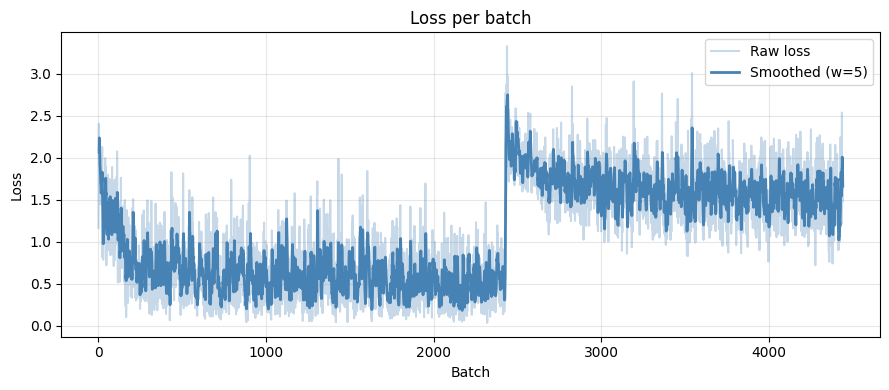

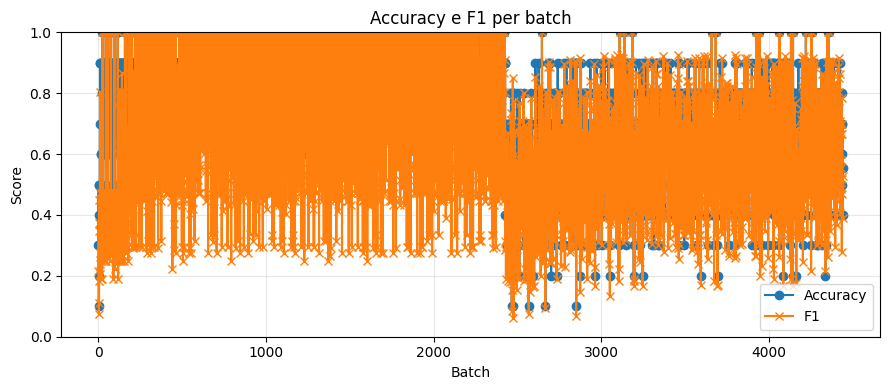

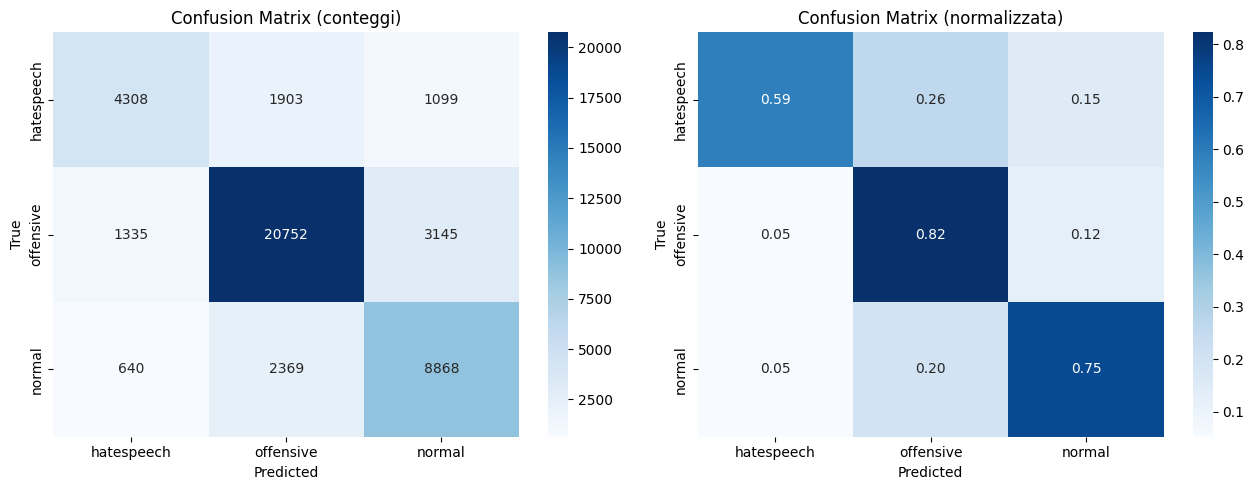

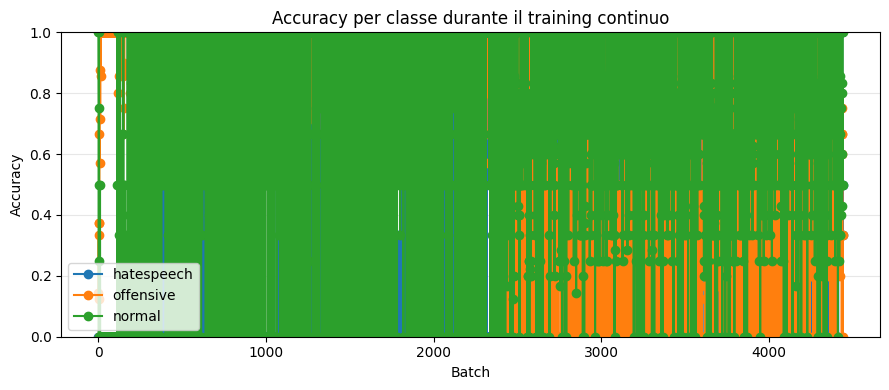

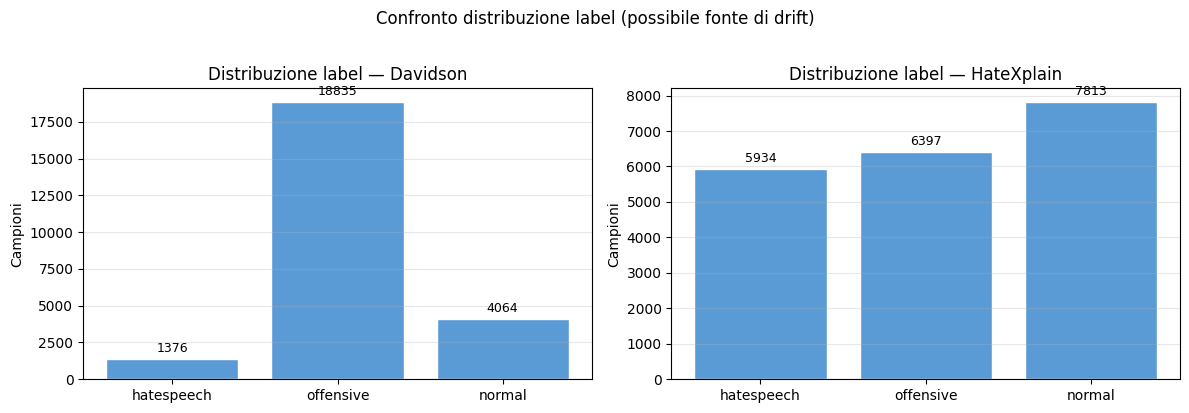

In [ ]:
# ─── CONFIG ──────────────────────────────────────────────────────────────────

BATCH_SIZE = 10
BUFFER_SIZE = 20
LR = 1e-5
label_map = {"hatespeech": 0, "offensive": 1, "normal": 2}

# ─── STRATEGY ────────────────────────────────────────────────────────────────

# Cambia qui per testare strategie diverse
strategy = ReplayStrategy(buffer_size=BUFFER_SIZE)
# strategy = EWCStrategy(model=model, lambda_=0.4)
# strategy = DistillationStrategy(model=model, alpha=0.5, temperature=2.0)

# ─── TRAINER ─────────────────────────────────────────────────────────────────

trainer = ContinualTrainer(model=model, tokenizer=tokenizer, device=device, lr=LR)
trainer.replay       = strategy if isinstance(strategy, ReplayStrategy)       else None
trainer.ewc          = strategy if isinstance(strategy, EWCStrategy)          else None
trainer.distillation = strategy if isinstance(strategy, DistillationStrategy) else None

#  ─── TEST ────────────────────────────────────────────────────────────

test_stream = full_stream[:200]  # 2 batch da 10 elementi ciascuno, solo per test


# ─── TRAIN ───────────────────────────────────────────────────────────────────

losses, flat_preds, flat_labels = trainer.train_continual(
    full_stream,
    label_map=label_map
)

# ─── METRICHE GLOBALI ────────────────────────────────────────────────────────

acc = compute_accuracy(flat_preds, flat_labels)
f1  = compute_f1(flat_preds, flat_labels)
print(f"\nAccuracy globale : {acc:.4f}")
print(f"F1 globale       : {f1:.4f}")

# ─── EVAL PER SORGENTE ───────────────────────────────────────────────────────
# Valuta separatamente su Davidson e HateXplain per misurare lo shift

stream_davidson   = [b for b in full_stream if b["source"].iloc[0] == "davidson"]
stream_hatexplain = [b for b in full_stream if b["source"].iloc[0] == "hatexplain"]

preds_dv,  labels_dv  = trainer.evaluate(stream_davidson,   label_map)
preds_hx,  labels_hx  = trainer.evaluate(stream_hatexplain, label_map)

print(f"\nDavidson   — Acc: {compute_accuracy(preds_dv, labels_dv):.4f} | F1: {compute_f1(preds_dv, labels_dv):.4f}")
print(f"HateXplain — Acc: {compute_accuracy(preds_hx, labels_hx):.4f} | F1: {compute_f1(preds_hx, labels_hx):.4f}")

# ─── PLOT ────────────────────────────────────────────────────────────────────

plot_loss(losses)
plot_batch_metrics(flat_preds, flat_labels, batch_size=BATCH_SIZE)
plot_conf_matrix(flat_preds, flat_labels, label_map)
plot_classwise_accuracy(flat_preds, flat_labels, label_map, batch_size=BATCH_SIZE)
plot_label_distribution(df_dv, df_hx, label_map)